
# Member 1 — Dataset Understanding & Data Quality Analysis

## Objectives
- Understand dataset structure
- Inspect dataset quality
- Handle missing values
- Analyze duplicates


In [43]:
import os
import pandas as pd

# Load dataset with a safe path fallback
# First tries your local project path, then tries common relative paths if the notebook is moved
dataset_paths = [
    r"C:\Users\Aryan\Desktop\NLP\NLP-Sentiment-Analysis\Data set\dataset -P676 (1).xlsx",
    "dataset -P676 (1).xlsx",
    os.path.join("Data set", "dataset -P676 (1).xlsx"),
    "/mnt/data/dataset -P676 (1).xlsx"
]

for path in dataset_paths:
    if os.path.exists(path):
        dataset_path = path
        break
else:
    raise FileNotFoundError("Dataset file not found. Please keep 'dataset -P676 (1).xlsx' in the notebook folder or Data set folder.")

# Read Excel dataset
df = pd.read_excel(dataset_path)

print("Dataset loaded from:", dataset_path)
df.head()


Dataset loaded from: dataset -P676 (1).xlsx


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


## Dataset Inspection

In [44]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (1440, 3)

Columns:
Index(['title', 'rating', 'body'], dtype='object')

Data Types:
title     object
rating     int64
body      object
dtype: object


## Identified Important Columns

In [45]:

title_column = "title"
rating_column = "rating"
body_column = "body"

print("Title Column:", title_column)
print("Rating Column:", rating_column)
print("Body Column:", body_column)


Title Column: title
Rating Column: rating
Body Column: body


## Missing Value Analysis

In [46]:

missing_values = df.isnull().sum()
missing_values


,0
title,0
rating,0
body,0


## Handling Missing Values

In [47]:

# Remove rows with missing important review text
important_cols = [col for col in ["title", "rating", "body"] if col != "None"]

cleaned_df = df.dropna(subset=important_cols)

print("Original Shape:", df.shape)
print("After Removing Missing Values:", cleaned_df.shape)


Original Shape: (1440, 3)
After Removing Missing Values: (1440, 3)


## Duplicate Analysis

In [48]:

duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

if "title" != "None":
    print("Duplicate Titles:", df["title"].duplicated().sum())

if "body" != "None":
    print("Duplicate Bodies:", df["body"].duplicated().sum())


Duplicate Rows: 0
Duplicate Titles: 89
Duplicate Bodies: 0


## Remove Duplicate Rows

In [49]:

df_no_duplicates = cleaned_df.drop_duplicates()

print("Shape Before Removing Duplicates:", cleaned_df.shape)
print("Shape After Removing Duplicates:", df_no_duplicates.shape)


Shape Before Removing Duplicates: (1440, 3)
Shape After Removing Duplicates: (1440, 3)


## Final Dataset Summary

In [50]:

print(df_no_duplicates.info())

df_no_duplicates.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Good phone for budget buyers. Sound quality is...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


# Member-2 Language Detection & Multilingual Analysis

## Objectives:

1. Language Detection
2. Language Distribution Analysis
3. Mixed-language Detection
4. Transliteration Detection


In [51]:
!pip install --upgrade pip setuptools wheel

In [52]:
!pip install langdetect

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect

# Create Language Detection Function

In [54]:
def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

# Apply Language Detection

In [55]:
df_processed['language'] = df_processed['body_cleaned'].apply(
    detect_language
)

# Check Output

In [56]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,en
1,camera quality is low,en
2,got the mobile on the launch date battery must...,en
3,1 it doesn t work with 5 0ghz wifi frequency 2...,en
4,not worth buying faulty software poor display ...,en
5,i will never purchase samsung phones phone is ...,en
6,this is worst samsung mobile i have seen from ...,en
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 pm बत...,hi
8,the phone hangs a lot and is very slow i recei...,en
9,very poor quality camera found box seal damage...,en


# Convert Language Codes

In [57]:
language_map = {
    "en": "English",
    "hi": "Hindi",
    "ta": "Tamil",
    "te": "Telugu"
}

df_processed["language"] = (
    df_processed["language"]
    .map(language_map)
    .fillna("Other")
)

In [58]:
df_processed[['body_cleaned', 'language']].head(10)

,body_cleaned,language
0,very disappointed with the overall performance...,English
1,camera quality is low,English
2,got the mobile on the launch date battery must...,English
3,1 it doesn t work with 5 0ghz wifi frequency 2...,English
4,not worth buying faulty software poor display ...,English
5,i will never purchase samsung phones phone is ...,English
6,this is worst samsung mobile i have seen from ...,English
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 pm बत...,Hindi
8,the phone hangs a lot and is very slow i recei...,English
9,very poor quality camera found box seal damage...,English


# Language Distribution Analysis

In [59]:
from langdetect import detect

def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"

df_processed['language'] = df_processed['body'].apply(
    detect_language
)

In [60]:
language_percentage = (
    df_processed['language']
    .value_counts(normalize=True) * 100
)

print(language_percentage)

language
en    97.638889
hi     0.763889
id     0.347222
ca     0.208333
fr     0.208333
et     0.208333
af     0.138889
lv     0.069444
ml     0.069444
sk     0.069444
so     0.069444
nl     0.069444
no     0.069444
ro     0.069444
Name: proportion, dtype: float64


In [61]:
print(
    df_processed['language'].unique()
)

['en' 'hi' 'af' 'ca' 'fr' 'id' 'lv' 'ml' 'et' 'sk' 'so' 'nl' 'no' 'ro']


## Check language counts



In [62]:
print(df_processed['language'].value_counts())

language
en    1406
hi      11
id       5
ca       3
fr       3
et       3
af       2
lv       1
ml       1
sk       1
so       1
nl       1
no       1
ro       1
Name: count, dtype: int64


## DOMINANT LANGUAGE

In [63]:
dominant_language = (
    df_processed['language']
    .mode()[0]
)

print("\nDominant Language:")
print(dominant_language)




Dominant Language:
en


## LANGUAGE DISTRIBUTION
### CHART


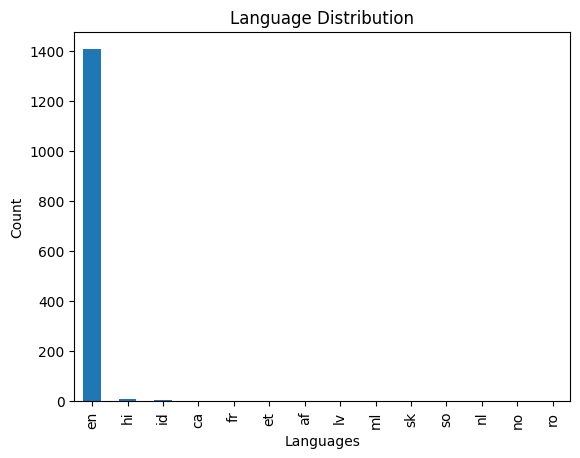

In [64]:
df_processed['language'].value_counts().plot(
    kind='bar'
)

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Count")

plt.show()

## MIXED LANGUAGE
### DETECTION


In [65]:
def detect_mixed_language(text):

    text = str(text)

    has_english = any(
        ord(char) < 128 for char in text
    )

    has_telugu = any(
        '\u0C00' <= char <= '\u0C7F'
        for char in text
    )

    has_tamil = any(
        '\u0B80' <= char <= '\u0BFF'
        for char in text
    )

    if has_english and (
        has_telugu or has_tamil
    ):
        return "Mixed"

    return "Single"


df_processed['mixed_language'] = (
    df_processed['body']
    .apply(detect_mixed_language)
)

print("\nMixed Language Statistics:")
print(
    df_processed['mixed_language']
    .value_counts()
)




Mixed Language Statistics:
mixed_language
Single    1440
Name: count, dtype: int64


 ## TRANSLITERATION
### DETECTION

In [66]:
transliterated_words = [
    'bahut',
    'accha',
    'mast',
    'undi',
    'bagundi',
    'acha'
]


def transliteration_detection(text):

    text = str(text).lower()

    for word in transliterated_words:

        if word in text:
            return "Yes"

    return "No"


df_processed['transliteration'] = (
    df_processed['body']
    .apply(transliteration_detection)
)

print("\nTransliteration Statistics:")
print(
    df_processed['transliteration']
    .value_counts()
)


Transliteration Statistics:
transliteration
No     1432
Yes       8
Name: count, dtype: int64


##  OUTPUT

In [67]:
print(
    df_processed[
        [
            'body',
            'language',
            'mixed_language',
            'transliteration'
        ]
    ].head(10)
)


                                                body language mixed_language  \
0  Very disappointed with the overall performance...       en         Single   
1                              Camera quality is low       en         Single   
2  Got the mobile on the launch date,Battery must...       en         Single   
3  1. It doesn't work with 5.0GHz WiFi frequency....       en         Single   
4  Not worth buying....faulty software, poor disp...       en         Single   
5  I will never purchase Samsung phones. Phone is...       en         Single   
6  This is worst samsung mobile I have seen from ...       en         Single   
7  मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...       hi         Single   
8  The phone hangs a lot and is very slow. I rece...       en         Single   
9  Very poor quality camera .Found box seal damag...       en         Single   

  transliteration  
0              No  
1              No  
2              No  
3              No  
4              No  

## FINAL REPORT

In [68]:
df_processed.to_csv(
    "language_analysis_report.csv",
    index=False
)

print("\nFinal Report Saved Successfully")


Final Report Saved Successfully


# Member -3 ,Aryan Part 3 - Encoding, Cleaning & Preprocessing

## Objectives:
1. Encoding and Unicode Checking
2. Text Cleaning
3. Combine Title + Body
4. Initial Text Standardization

This section performs only Member 3 tasks: encoding checks, Unicode normalization, multilingual text cleaning, and preparation of final cleaned text columns for downstream members.

**Note:** This section uses Member 1's `df_no_duplicates` output if it is available. If the notebook is run from this section directly, it safely falls back to `cleaned_df` or `df` so that `df_member3` is always created properly.


In [69]:
# Import required libraries for text cleaning and preprocessing

# re is used for removing URLs, symbols, punctuation, and extra spaces
import re

# unicodedata is used for Unicode normalization of multilingual text
import unicodedata

# pandas is used for dataframe handling and summary report creation
import pandas as pd

# BeautifulSoup is used to remove HTML tags from review text
from bs4 import BeautifulSoup


In [70]:
# Create a separate working dataframe for Member 3
# Priority:
# 1. Use df_no_duplicates from Member 1 if it exists
# 2. Otherwise use cleaned_df if available
# 3. Otherwise use original df as a fallback
# This avoids NameError and keeps Member 1 data unchanged

if 'df_no_duplicates' in globals():
    df_member3 = df_no_duplicates.copy()
    source_used = 'df_no_duplicates'
elif 'cleaned_df' in globals():
    df_member3 = cleaned_df.copy()
    source_used = 'cleaned_df'
elif 'df' in globals():
    df_member3 = df.copy()
    source_used = 'df'
else:
    raise NameError("No dataframe found. Please run the dataset loading cell first.")

# Display shape for quick verification
print(f"Member 3 input source: {source_used}")
print(f"Member 3 input shape: {df_member3.shape}")

# Preview first few records
df_member3.head()


Member 3 input source: df_no_duplicates
Member 3 input shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [71]:
# Define required columns for Member 3 processing
# title  -> review title / heading
# body   -> main review text
# rating -> rating or sentiment-related value

required_columns = ['title', 'body', 'rating']

# Check whether all required columns are present in df_member3
missing_columns = [col for col in required_columns if col not in df_member3.columns]

# Raise an error if any required column is missing
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Confirm required columns are available
print('All required columns are available for Member 3:', required_columns)


All required columns are available for Member 3: ['title', 'body', 'rating']


In [72]:
# Function to detect likely broken or unreadable characters in text
# Broken characters usually happen because of encoding mismatch while reading multilingual data
# Examples: �, Ã, Â, â, ???

def has_broken_characters(text):
    # Convert missing values to an empty string for safe processing
    text = '' if pd.isna(text) else str(text)

    # Common broken-character patterns seen in corrupted Unicode text
    broken_patterns = ['�', 'Ã', 'Â', 'â', '€', '™', '???']

    # Return True if any broken pattern is found in the text
    return any(pattern in text for pattern in broken_patterns)

# Count rows with broken characters in title and body separately
broken_title_count = df_member3['title'].apply(has_broken_characters).sum()
broken_body_count = df_member3['body'].apply(has_broken_characters).sum()

# Display a compact broken-character report
print('Broken Character Report')
print('-----------------------')
print(f"Rows with broken characters in title: {broken_title_count}")
print(f"Rows with broken characters in body: {broken_body_count}")


Broken Character Report
-----------------------
Rows with broken characters in title: 0
Rows with broken characters in body: 2


In [73]:
# Function to normalize Unicode text into a consistent form
# Unicode normalization helps maintain proper representation of multilingual scripts
# such as Hindi, Telugu, Tamil, and English mixed text

def normalize_unicode(text):
    # Convert missing values to an empty string
    text = '' if pd.isna(text) else str(text)

    # NFKC standardizes visually similar Unicode characters into a consistent form
    normalized_text = unicodedata.normalize('NFKC', text)

    # Return normalized text
    return normalized_text


In [74]:
# Function to clean multilingual text while preserving Hindi, Telugu, and Tamil scripts
# This function removes noise but keeps useful multilingual review content

def clean_multilingual_text(text):
    # Normalize Unicode first to reduce encoding inconsistencies
    text = normalize_unicode(text)

    # Remove HTML tags if present in review text
    # Example: <br>, <p>, <div>
    text = BeautifulSoup(text, 'html.parser').get_text(' ')

    # Remove URLs from the text
    # Example: https://example.com or www.example.com
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Convert English characters to lowercase
    # This does not affect Hindi, Telugu, or Tamil characters
    text = text.lower()

    # Remove unwanted symbols and punctuation while preserving multilingual scripts
    # Kept ranges:
    # a-z, A-Z, 0-9       -> English letters and numbers
    # ऀ-ॿ      -> Hindi / Devanagari
    # ఀ-౿      -> Telugu
    # ஀-௿      -> Tamil
    # \s                 -> spaces
    text = re.sub(
        r'[^a-zA-Z0-9\sऀ-ॿఀ-౿஀-௿]',
        ' ',
        text
    )

    # Replace multiple spaces, tabs, or newlines with a single space
    text = re.sub(r'\s+', ' ', text)

    # Remove leading and trailing spaces
    text = text.strip()

    # Return final cleaned text
    return text


In [75]:
# Apply the cleaning function on title and body columns

# Clean title text and store it in clean_title column
df_member3['clean_title'] = df_member3['title'].apply(clean_multilingual_text)

# Clean body text and store it in clean_body column
df_member3['clean_body'] = df_member3['body'].apply(clean_multilingual_text)

# Show original and cleaned columns for quick validation
df_member3[['title', 'clean_title', 'body', 'clean_body']].head()


,title,clean_title,body,clean_body
0,Horrible product,horrible product,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,camera quality is not like 48 megapixel,Camera quality is low,camera quality is low
2,Overall,overall,"Got the mobile on the launch date,Battery must...",got the mobile on the launch date battery must...
3,A big no from me,a big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,1 it doesn t work with 5 0ghz wifi frequency 2...
4,Put your money somewhere else,put your money somewhere else,"Not worth buying....faulty software, poor disp...",not worth buying faulty software poor display ...


In [76]:
# Combine clean_title and clean_body into one final review_text column
# This final column will be used by the next members for tokenization, analysis, and modeling

df_member3['review_text'] = (df_member3['clean_title'] + ' ' + df_member3['clean_body']).str.strip()

# Replace repeated spaces again after concatenation
df_member3['review_text'] = df_member3['review_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Preview the final combined review text
df_member3[['clean_title', 'clean_body', 'review_text']].head()


,clean_title,clean_body,review_text
0,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...
1,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...
2,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...
3,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...
4,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...


In [77]:
# Check whether cleaning created any empty text rows
# Empty rows may occur if title/body had only symbols, URLs, or missing text

empty_clean_title_count = (df_member3['clean_title'] == '').sum()
empty_clean_body_count = (df_member3['clean_body'] == '').sum()
empty_review_count = (df_member3['review_text'] == '').sum()

# Display empty-text report
print('Empty Text Report After Cleaning')
print('--------------------------------')
print(f"Rows with empty clean_title: {empty_clean_title_count}")
print(f"Rows with empty clean_body: {empty_clean_body_count}")
print(f"Rows with empty review_text: {empty_review_count}")


Empty Text Report After Cleaning
--------------------------------
Rows with empty clean_title: 0
Rows with empty clean_body: 0
Rows with empty review_text: 0


In [78]:
# Create a compact Member 3 summary report
# This report shows important preprocessing observations

member3_summary = pd.DataFrame({
    'Metric': [
        'Input source used',
        'Input rows',
        'Input columns',
        'Rows with broken title chars',
        'Rows with broken body chars',
        'Rows with empty clean_title',
        'Rows with empty clean_body',
        'Rows with empty review_text',
        'Final rows available'
    ],
    'Value': [
        source_used,
        len(df_member3),
        df_member3.shape[1],
        int(broken_title_count),
        int(broken_body_count),
        int(empty_clean_title_count),
        int(empty_clean_body_count),
        int(empty_review_count),
        len(df_member3)
    ]
})

# Display summary table
member3_summary


,Metric,Value
0,Input source used,df_no_duplicates
1,Input rows,1440
2,Input columns,6
3,Rows with broken title chars,0
4,Rows with broken body chars,2
5,Rows with empty clean_title,0
6,Rows with empty clean_body,0
7,Rows with empty review_text,0
8,Final rows available,1440


In [79]:
# Keep only final columns required after Member 3 preprocessing
# This keeps the Member 3 output clean and easy to share

member3_cleaned_df = df_member3[
    [
        'title',
        'body',
        'rating',
        'clean_title',
        'clean_body',
        'review_text'
    ]
].copy()

# Save cleaned dataset using UTF-8 with BOM for better Excel compatibility
member3_cleaned_df.to_csv('member3_cleaned_dataset.csv', index=False, encoding='utf-8-sig')

# Keep df_member3 as the final Member 3 dataframe
df_member3 = member3_cleaned_df.copy()

# Compatibility for the remaining notebook sections that already expect df_processed,
# title_cleaned, and body_cleaned column names.
# This does not change Member 3 final output; it only prevents later cells from breaking.
df_processed = df_member3.copy()
df_processed['title_cleaned'] = df_processed['clean_title']
df_processed['body_cleaned'] = df_processed['clean_body']

# Confirm save location and final shape
print('Saved file: member3_cleaned_dataset.csv')
print(f"Final Member 3 dataset shape: {df_member3.shape}")
print('df_processed compatibility dataframe created for next notebook sections.')


Saved file: member3_cleaned_dataset.csv
Final Member 3 dataset shape: (1440, 6)
df_processed compatibility dataframe created for next notebook sections.


## Member 3 Conclusion

In this section, encoding checking and preprocessing were performed on the multilingual review dataset. The title and body columns were checked for broken or unreadable characters, Unicode normalization was applied, and multilingual text was cleaned while preserving Hindi, Telugu, and Tamil characters.

The cleaned title and cleaned body were combined into a single `review_text` column. The final cleaned dataset was saved as `member3_cleaned_dataset.csv` and is ready for the next stages such as tokenization, stopword removal, language analysis, and modeling.


#Member 4 — Tokenization, Stopwords & Lemmatization

## Objectives:
1. Language-wise Tokenization
2. Language-specific Stopword Removal
3. Stemming
4. Lemmatization

### Tokenization

Tokenization is the process of breaking a stream of text into words, phrases, symbols, or other meaningful elements called tokens. These tokens are then used as input for further processing.

In [80]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenization
df_processed['title_tokens'] = df_processed['title_cleaned'].apply(word_tokenize)
df_processed['body_tokens'] = df_processed['body_cleaned'].apply(word_tokenize)

# Display sample tokens
display(df_processed[['title_tokens', 'body_tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,title_tokens,body_tokens
0,"[horrible, product]","[very, disappointed, with, the, overall, perfo..."
1,"[camera, quality, is, not, like, 48, megapixel]","[camera, quality, is, low]"
2,[overall],"[got, the, mobile, on, the, launch, date, batt..."
3,"[a, big, no, from, me]","[1, it, doesn, t, work, with, 5, 0ghz, wifi, f..."
4,"[put, your, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d..."


### Removing Stop Words

Stop words are common words (like 'the', 'is', 'and') that often carry little meaning in text analysis and can be removed to reduce noise and improve processing efficiency. We will use NLTK's list of English stop words.

In [101]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Keep important negation words
negation_words = {'not', 'no', 'nor', 'never'}

stop_words = stop_words - negation_words

# Function to remove stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stopword removal
df_processed['title_tokens_cleaned'] = df_processed['title_tokens'].apply(remove_stopwords)
df_processed['body_tokens_cleaned'] = df_processed['body_tokens'].apply(remove_stopwords)

# Display sample cleaned tokens
display(df_processed[['title_tokens_cleaned', 'body_tokens_cleaned']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title_tokens_cleaned,body_tokens_cleaned
0,"[horrible, product]","[disappointed, overall, performance, samsung]"
1,"[camera, quality, not, like, 48, megapixel]","[camera, quality, low]"
2,[overall],"[got, mobile, launch, date, battery, must, app..."
3,"[big, no]","[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o..."
4,"[put, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d..."


### Lemmatization

Lemmatization is the process of grouping together the inflected forms of a word so they can be analyzed as a single item, identified by the word's lemma or dictionary form. For example, 'running', 'runs', and 'ran' would all be lemmatized to 'run'. This helps reduce the sparsity of the data and improves the efficiency and accuracy of text analysis tasks.

In [102]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the cleaned tokens
df_processed['title_tokens_lemmatized'] = df_processed['title_tokens_cleaned'].apply(lemmatize_tokens)
df_processed['body_tokens_lemmatized'] = df_processed['body_tokens_cleaned'].apply(lemmatize_tokens)

display(df_processed[['title_tokens_cleaned',
                      'title_tokens_lemmatized',
                      'body_tokens_cleaned',
                      'body_tokens_lemmatized']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,title_tokens_cleaned,title_tokens_lemmatized,body_tokens_cleaned,body_tokens_lemmatized
0,"[horrible, product]","[horrible, product]","[disappointed, overall, performance, samsung]","[disappointed, overall, performance, samsung]"
1,"[camera, quality, not, like, 48, megapixel]","[camera, quality, not, like, 48, megapixel]","[camera, quality, low]","[camera, quality, low]"
2,[overall],[overall],"[got, mobile, launch, date, battery, must, app...","[got, mobile, launch, date, battery, must, app..."
3,"[big, no]","[big, no]","[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o...","[1, work, 5, 0ghz, wifi, frequency, 2, 4ghz, o..."
4,"[put, money, somewhere, else]","[put, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d...","[not, worth, buying, faulty, software, poor, d..."


In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens back into strings for TF-IDF Vectorization
df_processed['title_text_lemmatized'] = df_processed['title_tokens_lemmatized'].apply(lambda x: ' '.join(x))
df_processed['body_text_lemmatized'] = df_processed['body_tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Initialize TF-IDF Vectorizers
tfidf_vectorizer_title = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for titles
tfidf_vectorizer_body = TfidfVectorizer(max_features=10000) # Limiting to 10000 features for body

# Fit and transform the title text
tfidf_features_title = tfidf_vectorizer_title.fit_transform(df_processed['title_text_lemmatized'])

# Fit and transform the body text
tfidf_features_body = tfidf_vectorizer_body.fit_transform(df_processed['body_text_lemmatized'])

print("Shape of TF-IDF features for titles:", tfidf_features_title.shape)
print("Shape of TF-IDF features for body:", tfidf_features_body.shape)

# Display a sample of the feature names for titles
print("\nSample TF-IDF feature names (titles):")
print(tfidf_vectorizer_title.get_feature_names_out()[:20])

# Display a sample of the feature names for body
print("\nSample TF-IDF feature names (body):")
print(tfidf_vectorizer_body.get_feature_names_out()[:20])

Shape of TF-IDF features for titles: (1440, 1072)
Shape of TF-IDF features for body: (1440, 5344)

Sample TF-IDF feature names (titles):
['10' '100' '1000' '10000' '10500' '10999' '10k' '11' '11k' '12' '12499'
 '128' '128gb' '12k' '13' '13k' '15' '15000' '15k' '1st']

Sample TF-IDF feature names (body):
['000' '0000' '000mah' '03' '03rd' '04' '07th' '09th' '0f' '0ghz' '10'
 '100' '1000' '10000' '100gb' '102' '10299' '103' '1039' '10499']


In [104]:
from scipy.sparse import hstack

# Function to map ratings to sentiment labels
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

# Apply the function to create a new 'sentiment' column
df_processed['sentiment'] = df_processed['rating'].apply(get_sentiment)

# Combine TF-IDF features for title and body
X = hstack([tfidf_features_title, tfidf_features_body])

# The target variable 'sentiment' is now created
y = df_processed['sentiment']

print("Shape of combined features (X):", X.shape)
print("Shape of target variable (y):", y.shape)
print("\nSample of target variable (y):")
print(y.head())

Shape of combined features (X): (1440, 6416)
Shape of target variable (y): (1440,)

Sample of target variable (y):
0    negative
1     neutral
2    positive
3    negative
4    negative
Name: sentiment, dtype: object


#Member 5 — Word Analysis & Feature Exploration

##Objectives:
1. Word Frequency Analysis
2. N-gram Analysis
3. Review Pattern Analysis
4. Visualization

#Import Required Libraries

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

#Create Positive, Neutral and Negative Review Datasets

In [106]:
positive_reviews = df_processed[
    df_processed['sentiment'] == 'positive'
]

neutral_reviews = df_processed[
    df_processed['sentiment'] == 'neutral'
]

negative_reviews = df_processed[
    df_processed['sentiment'] == 'negative'
]

print("Positive Reviews:", positive_reviews.shape[0])
print("Neutral Reviews:", neutral_reviews.shape[0])
print("Negative Reviews:", negative_reviews.shape[0])

Positive Reviews: 729
Neutral Reviews: 199
Negative Reviews: 512


##Interpretation

The dataset contains more positive reviews, indicating that most customers had a good experience with the product. However, a considerable number of negative reviews are also present, showing customer dissatisfaction regarding certain product features or performance issues.

#Word Frequency Analysis:
Word Frequency Analysis was performed to identify the most frequently occurring words in the review dataset after preprocessing and lemmatization.
#Combine All Review Text


In [107]:
all_words = ' '.join(
    df_processed['body_text_lemmatized']
).split()

#Most Common Words

In [108]:
word_frequency = Counter(all_words)

most_common_words = word_frequency.most_common(20)

print("Top 20 Most Common Words:")
print(most_common_words)

Top 20 Most Common Words:
[('phone', 1645), ('not', 1213), ('good', 1203), ('camera', 987), ('battery', 798), ('samsung', 667), ('quality', 633), ('mobile', 543), ('price', 354), ('day', 346), ('product', 330), ('also', 315), ('life', 296), ('display', 291), ('like', 282), ('no', 281), ('2', 275), ('buy', 257), ('screen', 253), ('use', 246)]


##Interpretation:
The frequent occurrence of words like “phone”, “camera”, and “battery” indicates that customers mainly discussed product features and performance.

Words such as “not” and “good” show that customers often expressed opinions and comparisons about product quality and user experience.

The analysis helps identify the major topics and concerns discussed in customer reviews.

#Convert Frequency to DataFrame

In [109]:
freq_df = pd.DataFrame(
    most_common_words,
    columns=['Word', 'Frequency']
)

freq_df

,Word,Frequency
0,phone,1645
1,not,1213
2,good,1203
3,camera,987
4,battery,798
5,samsung,667
6,quality,633
7,mobile,543
8,price,354
9,day,346


##Interprtation:
The top 20 most common words in the review dataset were visualized using a bar chart after preprocessing and lemmatization.

#Visualization — Most Common Words

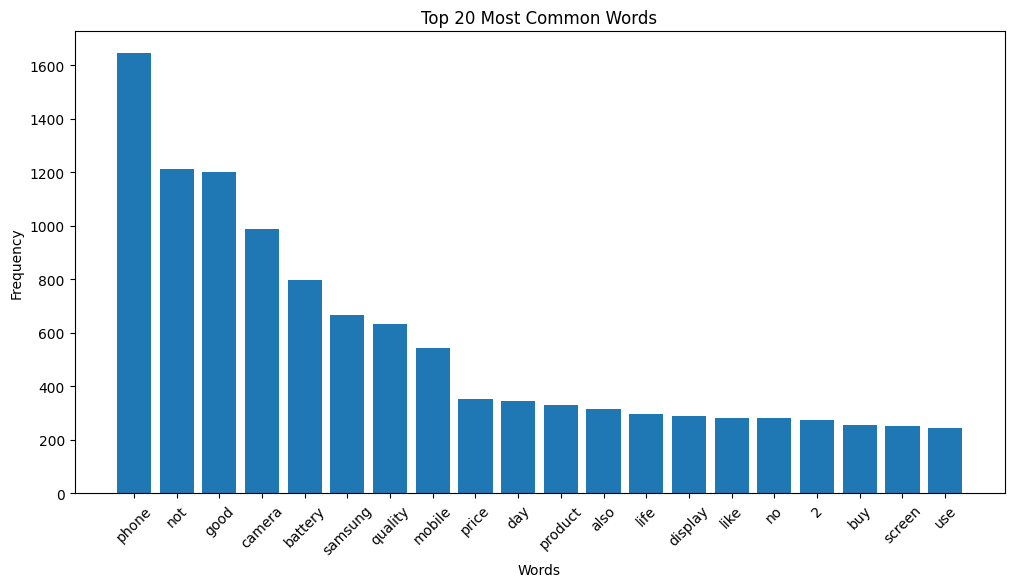

In [110]:
plt.figure(figsize=(12,6))

plt.bar(
    freq_df['Word'],
    freq_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top 20 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
The graph shows that words like “phone”, “camera”, “battery”, and “quality” appeared most frequently in customer reviews, indicating that users mainly discussed product features, performance, and user experience.

#Positive Review Word Analysis:
Positive Review Word Analysis was performed to identify the most frequently occurring words in positive customer reviews

In [111]:
positive_words = ' '.join(
    positive_reviews['body_text_lemmatized']
).split()

positive_frequency = Counter(
    positive_words
)

positive_common = positive_frequency.most_common(20)

positive_df = pd.DataFrame(
    positive_common,
    columns=['Word', 'Frequency']
)

positive_df

,Word,Frequency
0,good,882
1,phone,806
2,camera,577
3,battery,534
4,not,435
5,quality,325
6,samsung,272
7,price,254
8,life,213
9,day,203


#Positive Word Visualization

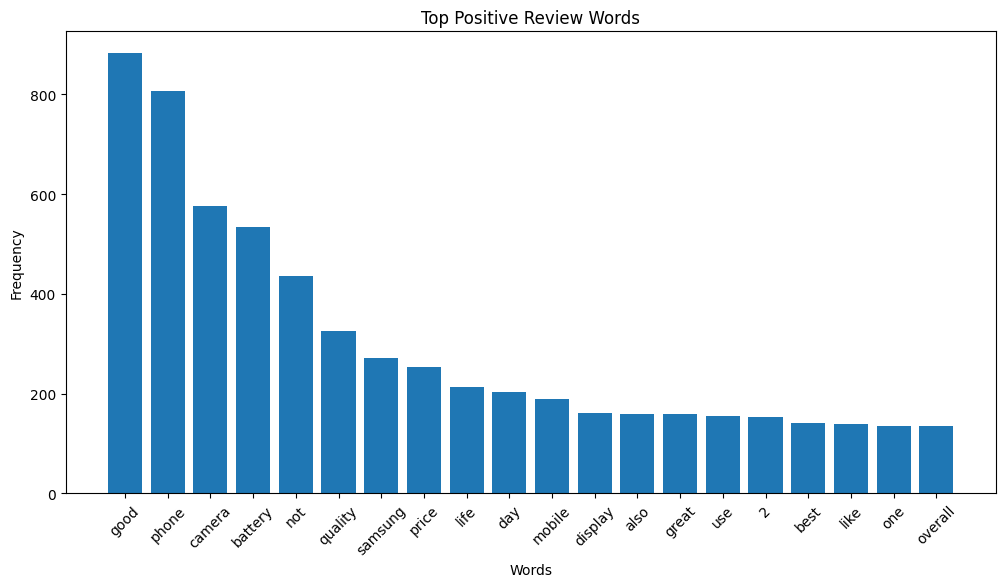

In [112]:
plt.figure(figsize=(12,6))

plt.bar(
    positive_df['Word'],
    positive_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Positive Review Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Words like “good”, “camera”, “battery”, and “quality” appeared frequently in positive reviews, indicating that customers were satisfied with product features, performance, and overall user experience

In [113]:
custom_stopwords = [
    'phone',
    'mobile',
    'samsung',
    'camera',
    'product',
    'amazon',
    'buy'
]

#Negative Review Word Analysis
Negative Review Word Analysis was performed to identify the most frequently occurring words in negative customer reviews.

In [114]:
negative_words = ' '.join(
    negative_reviews['body_text_lemmatized']
).split()

negative_frequency = Counter(
    negative_words
)

negative_common = negative_frequency.most_common(20)

negative_df = pd.DataFrame(
    negative_common,
    columns=['Word', 'Frequency']
)

negative_df

,Word,Frequency
0,phone,600
1,not,528
2,samsung,305
3,mobile,257
4,camera,249
5,quality,198
6,product,179
7,amazon,164
8,battery,156
9,buy,151


#Negative Word Visualization

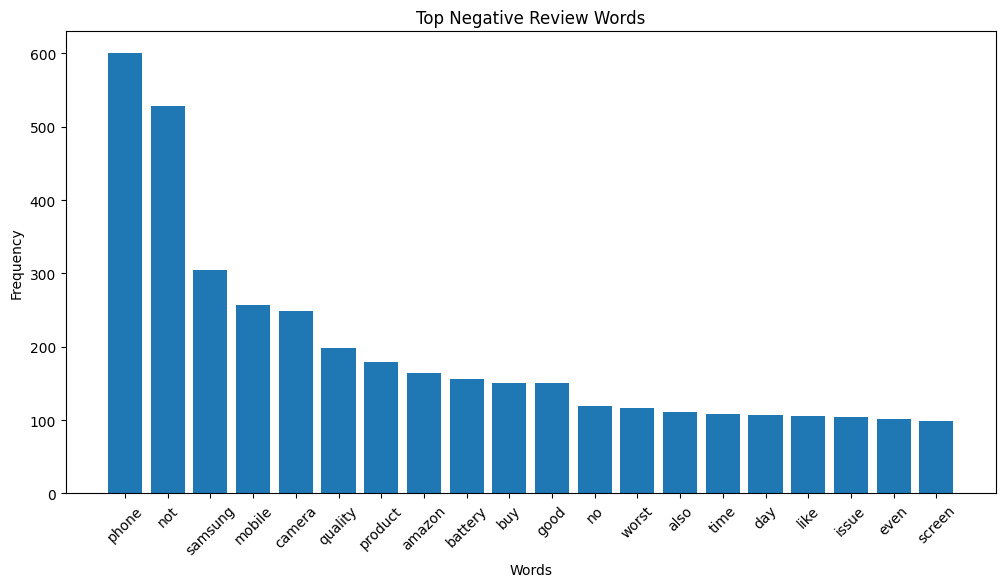

In [115]:
plt.figure(figsize=(12,6))

plt.bar(
    negative_df['Word'],
    negative_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Negative Review Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Words like “worst”, “issue”, “not”, and “buy” indicate customer dissatisfaction and complaints related to product quality and performance. Product-related words such as “phone”, “camera”, and “battery” appear frequently because users discussed product features while expressing negative experiences.

#Bigram Analysis

In [116]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df_processed['body_text_lemmatized']
)

bigram_counts = bigram_matrix.sum(axis=0)

bigram_freq = [
    (
        word,
        bigram_counts[0, idx]
    )
    for word, idx in
    bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['Bigram', 'Frequency']
)

bigram_df.head(20)

,Bigram,Frequency
0,camera quality,266
1,battery life,262
2,not good,134
3,price range,94
4,good battery,85
5,battery backup,80
6,finger print,78
7,good phone,70
8,quality not,69
9,quality good,64


#Bigram Visualization
Bigram Analysis was performed to identify the most frequently occurring two-word combinations in the review dataset.

Examples include:

camera quality,battery life,not good,price range




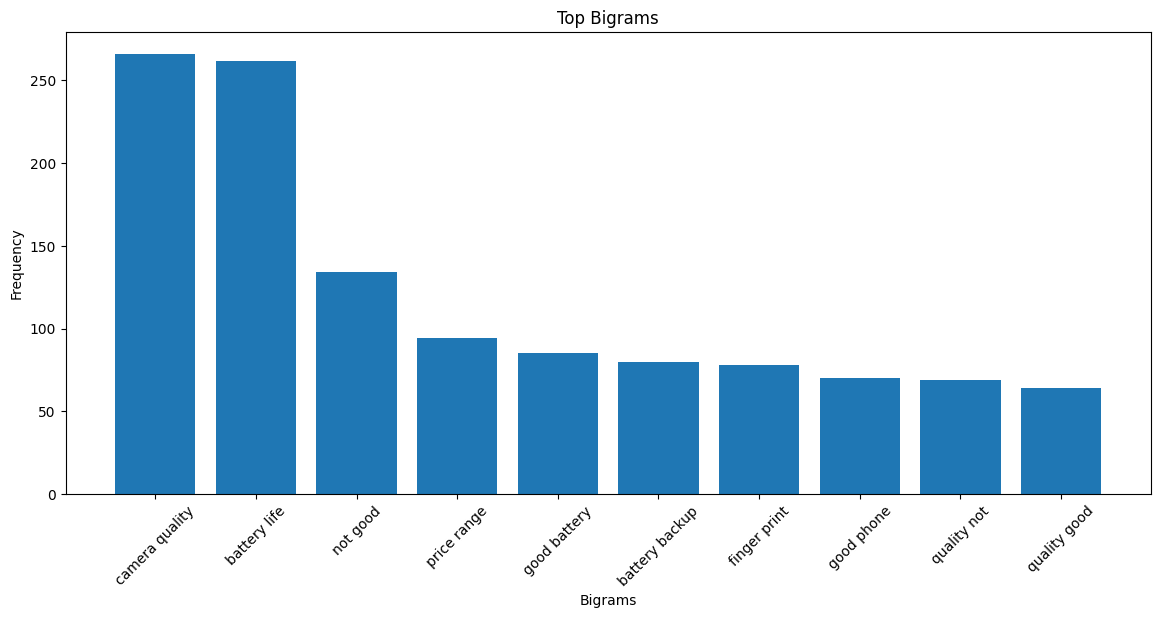

In [117]:
plt.figure(figsize=(14,6))

plt.bar(
    bigram_df['Bigram'][:10],
    bigram_df['Frequency'][:10]
)

plt.xticks(rotation=45)

plt.title("Top Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Frequent bigrams like “camera quality” and “battery life” indicate that customers mainly discussed product performance and features. Phrases such as “not good” reflect customer dissatisfaction, while “good battery” and “good camera” indicate positive user experiences. Bigram analysis helps capture meaningful review patterns and customer opinions more effectively than single-word analysis.

#Trigram Analysis

In [118]:
trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    max_features=20
)

trigram_matrix = trigram_vectorizer.fit_transform(
    df_processed['body_text_lemmatized']
)

trigram_counts = trigram_matrix.sum(axis=0)

trigram_freq = [
    (
        word,
        trigram_counts[0, idx]
    )
    for word, idx in
    trigram_vectorizer.vocabulary_.items()
]

trigram_freq = sorted(
    trigram_freq,
    key=lambda x: x[1],
    reverse=True
)

trigram_df = pd.DataFrame(
    trigram_freq,
    columns=['Trigram', 'Frequency']
)

trigram_df.head(20)

,Trigram,Frequency
0,battery life good,47
1,camera quality not,41
2,good battery life,36
3,medium could not,34
4,could not loaded,34
5,camera quality good,33
6,finger print reader,29
7,samsung galaxy m12,28
8,quality not good,26
9,camera quality poor,25


#Trigram Visualization
Trigram Analysis was performed to identify the most frequent three-word combinations in the review dataset. This helps capture complete customer opinions and product-related phrases more clearly than unigram or bigram analysis.

Examples include:

battery life good,camera quality not,good battery life,camera quality poor.

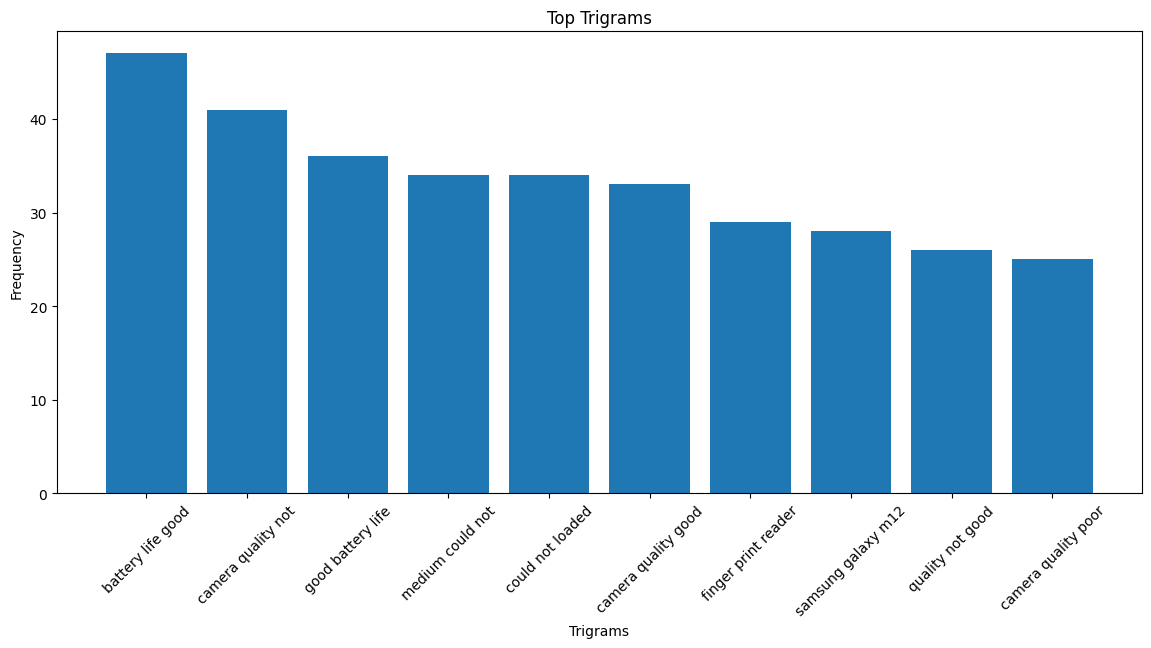

In [119]:
plt.figure(figsize=(14,6))

plt.bar(
    trigram_df['Trigram'][:10],
    trigram_df['Frequency'][:10]
)

plt.xticks(rotation=45)

plt.title("Top Trigrams")
plt.xlabel("Trigrams")
plt.ylabel("Frequency")

plt.show()

##Interpreation:
The trigram results show that customers mainly discussed battery performance, camera quality, and overall product experience. Positive phrases like “good battery life” indicate customer satisfaction, while phrases such as “camera quality not” and “camera quality poor” reflect negative feedback. The analysis helps identify detailed customer sentiments and common review patterns in the dataset

#Word Cloud Visualization
Word Cloud Visualization was created to display the most frequently occurring words in positive reviews. Larger words in the word cloud represent higher frequency in customer reviews.

#Positive Reviews Word Cloud

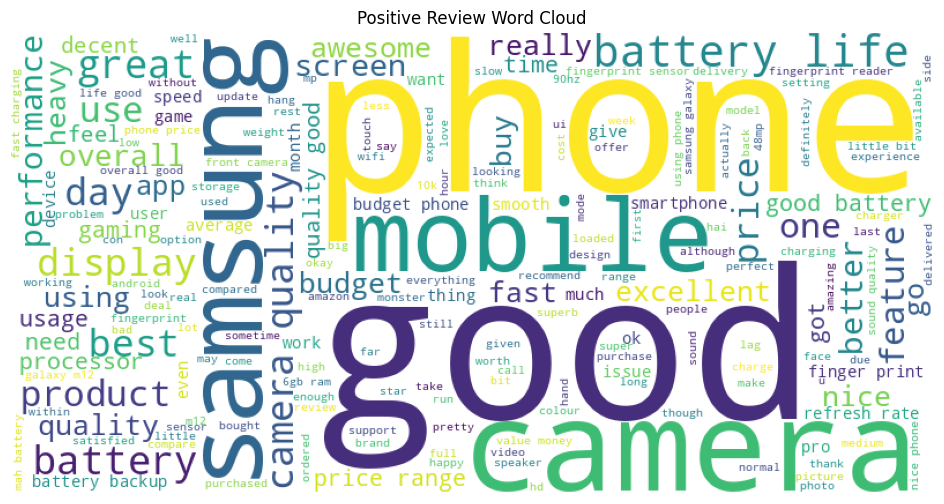

In [120]:
positive_text = ' '.join(
    positive_reviews['body_text_lemmatized']
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud_positive)

plt.axis('off')

plt.title("Positive Review Word Cloud")

plt.show()

##Interpretation:
Words like “good”, “phone”, “camera”, “battery”, and “quality” appear prominently, indicating that customers were mainly satisfied with product performance, camera quality, and battery life. The visualization helps quickly identify the major positive aspects discussed by users.

#Negative Reviews Word Cloud
Negative Review Word Cloud was created to visualize the most frequently occurring words in negative customer reviews. Larger words indicate higher frequency in negative feedback.

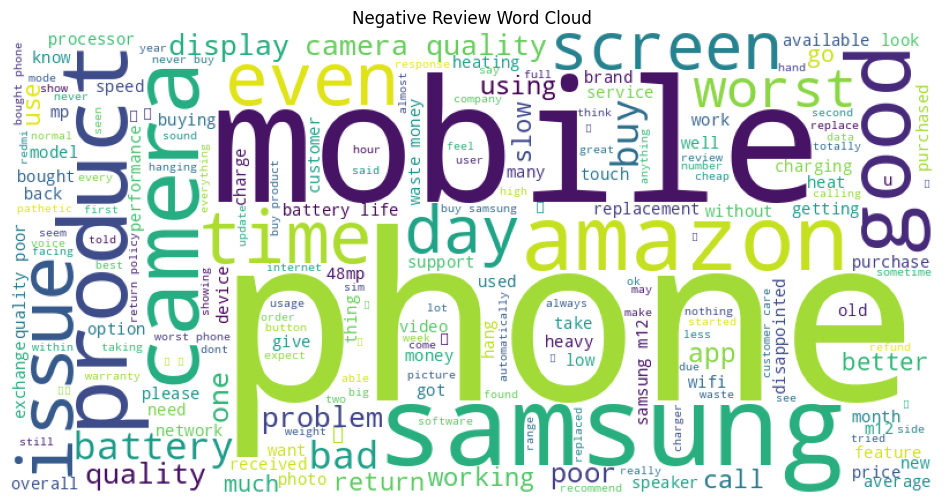

In [121]:
negative_text = ' '.join(
    negative_reviews['body_text_lemmatized']
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud_negative)

plt.axis('off')

plt.title("Negative Review Word Cloud")

plt.show()

##Interpretation:
Words like “phone”, “samsung”, “screen”, “worst”, “problem”, and “bad” appear prominently, showing that customers mainly complained about product quality, screen issues, performance problems, and overall user experience. The visualization helps identify the major negative concerns discussed by customers.

#Review Length Analysis
Review Length Analysis calculates the number of words present in each processed review using the review_length feature. The histogram visualizes how review lengths are distributed across the dataset.

In [122]:
df_processed['review_length'] = (
    df_processed['body_text_lemmatized']
    .apply(lambda x: len(x.split()))
)

df_processed[
    ['review_length', 'sentiment']
].head()

,review_length,sentiment
0,4,negative
1,3,neutral
2,38,positive
3,40,negative
4,24,negative


#Review Length Distribution

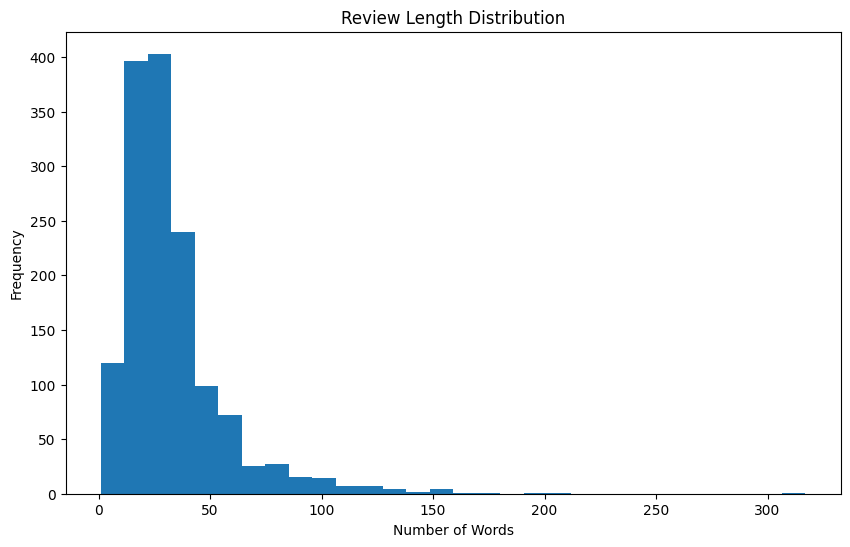

In [123]:
plt.figure(figsize=(10,6))

plt.hist(
    df_processed['review_length'],
    bins=30
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Most reviews contain a small to medium number of words, while only a few reviews are very long. This indicates that customers generally provide short and concise feedback, with some users giving detailed explanations about their experience.

#Review Pattern Analysis
Review Pattern Analysis calculates the average review length for each sentiment category (positive, neutral, and negative). The bar chart compares the average number of words used in different types of reviews.

In [124]:
review_pattern = df_processed.groupby(
    'sentiment'
)['review_length'].mean()

print(review_pattern)

sentiment
negative    32.218750
neutral     35.291457
positive    32.810700
Name: review_length, dtype: float64


#Review Pattern Visualization

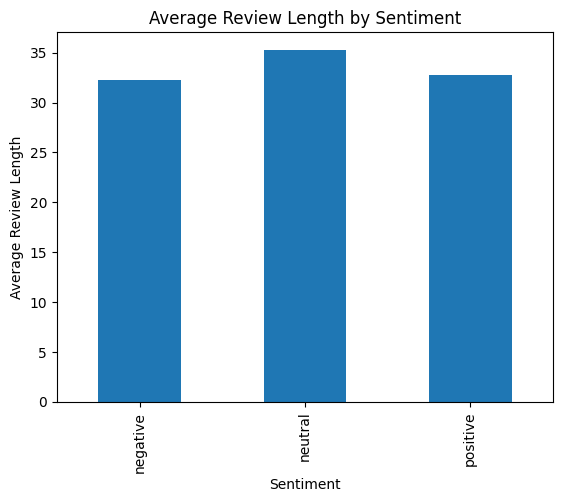

In [125]:
review_pattern.plot(
    kind='bar'
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")

plt.show()

##Interpretation:
Neutral reviews have slightly higher average review lengths compared to positive and negative reviews. This indicates that neutral reviewers tend to provide more detailed explanations, while positive and negative reviews are comparatively shorter and more direct.

In [126]:
df_processed.to_csv(
    "member5_word_analysis_report.csv",
    index=False
)

print("Member 5 Report Saved Successfully")

Member 5 Report Saved Successfully


#Member 6 — Outlier Detection, Modeling Strategy
##Objectives:
* Outlier Detection
* Modeling Strategy Analysis
* Feature Extraction Preparation
* Final Insights & Documentation

#Outlier Detection
##Detect Extremely Short Reviews
This step identifies extremely short reviews by checking reviews with very few words (review_length < 3). Such reviews may not provide meaningful information for sentiment analysis.

In [127]:
# Detect reviews with very small length

short_reviews = df_processed[
    df_processed['review_length'] < 3
]

print("Number of Extremely Short Reviews:")
print(short_reviews.shape[0])

short_reviews[
    ['body', 'review_length']
].head()

Number of Extremely Short Reviews:
12


,body,review_length
15,Hitting issue,2
21,Dislike,1
27,Horrible product,2
61,Samsung is the beat,2
299,Good 🎤🎤🎤🎤😍🎤🎤🎤🎤🎤🎤🎤😍😍🎤🎤🎤🎤🎤🎤😍🎤😍😍🎤🎤🎤🎤😍🎤🎤🎤🎤🎤🎤🎤😍🎤🎤🎤🎤...,1


##Interpretation:
The analysis found 12 extremely short reviews, including texts like “Dislike” and “Hitting issue”. These reviews contain very limited information and may reduce the quality of NLP analysis and model performance.

#Detect Repeated Text Reviews
##Function to detect repeated words



In [128]:
def repeated_text_detection(text):

    words = str(text).split()

    if len(set(words)) <= 2 and len(words) > 3:
        return "Repeated"

    return "Normal"

df_processed['repeated_text'] = (
    df_processed['body_text_lemmatized']
    .apply(repeated_text_detection)
)

print(
    df_processed['repeated_text']
    .value_counts()
)

repeated_text
Normal    1440
Name: count, dtype: int64


##Interpretation:
The analysis identified whether reviews contain spam-like repetitive text patterns. Most reviews were classified as “Normal”, indicating that the dataset contains fewer repeated or low-quality spam reviews.

##Detect Spam Reviews
This step detects duplicate or spam-like reviews by checking whether the same review text appears multiple times in the dataset.

In [129]:
# Detect duplicate/spam-like reviews

spam_reviews = df_processed[
    df_processed['body']
    .duplicated(keep=False)
]

print("Possible Spam Reviews:")
print(spam_reviews.shape[0])

Possible Spam Reviews:
0


##Interpretation:
The analysis found 0 possible spam reviews, indicating that the dataset does not contain duplicate review texts and the review data is mostly genuine and unique.

##Detect Noisy Multilingual Content
This analysis checks whether reviews contain mixed languages such as English with Telugu or Tamil characters. It helps identify noisy multilingual content in the dataset.

In [130]:
# Detect reviews containing multiple scripts

def noisy_multilingual(text):

    text = str(text)

    has_english = any(ord(c) < 128 for c in text)

    has_telugu = any(
        '\u0C00' <= c <= '\u0C7F'
        for c in text
    )

    has_tamil = any(
        '\u0B80' <= c <= '\u0BFF'
        for c in text
    )

    if has_english and (
        has_telugu or has_tamil
    ):
        return "Mixed"

    return "Single"

df_processed['multilingual_type'] = (
    df_processed['body']
    .apply(noisy_multilingual)
)

print(
    df_processed['multilingual_type']
    .value_counts()
)

multilingual_type
Single    1440
Name: count, dtype: int64


##Interpretation:
The result shows that all 1440 reviews were classified as “Single” language reviews. This indicates that the dataset is clean and does not contain noisy mixed-language text, making it suitable for NLP preprocessing and modeling

#Translation vs Multilingual Modeling Analysis
This section compares two approaches for handling multilingual reviews in sentiment analysis:

Translation-based approach – translating all reviews into English before processing.
Multilingual modeling approach – directly using multilingual NLP models like mBERT and XLM-RoBERTa.
##Translation-based Approach

In [131]:
translation_approach = {
    "Method": "Translate all reviews into English",
    "Advantages": [
        "Simpler preprocessing",
        "Easy model training"
    ],
    "Disadvantages": [
        "Possible sentiment loss",
        "Translation errors"
    ]
}

print(translation_approach)

{'Method': 'Translate all reviews into English', 'Advantages': ['Simpler preprocessing', 'Easy model training'], 'Disadvantages': ['Possible sentiment loss', 'Translation errors']}


##Multilingual Modeling Approach

In [132]:
multilingual_models = [
    "mBERT",
    "XLM-RoBERTa"
]

print("Recommended Multilingual Models:")
print(multilingual_models)

Recommended Multilingual Models:
['mBERT', 'XLM-RoBERTa']


##Interpretation:

The translation-based approach is simpler and easier for preprocessing and model training, but it may lose sentiment meaning during translation.
Multilingual models can preserve original context and support multiple languages directly, making them more suitable for real-world multilingual sentiment analysis tasks.

#Feature Extraction Preparation
##Bag of Words
This step prepares text data using the Bag of Words (BoW) technique, where each review is converted into numerical word-frequency vectors using CountVectorizer

In [133]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000
)

bow_features = bow_vectorizer.fit_transform(
    df_processed['body_text_lemmatized']
)

print("Bag of Words Shape:")
print(bow_features.shape)


Bag of Words Shape:
(1440, 5000)


##Interpretation:
The generated feature matrix size is (1440, 5000), meaning:

* 1440 reviews were processed
* 5000 important words/features were extracted

##TF-IDF
This step uses the TF-IDF (Term Frequency–Inverse Document Frequency) technique to convert text reviews into numerical feature vectors by giving more importance to meaningful and unique words.

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

tfidf_features = tfidf_vectorizer.fit_transform(
    df_processed['body_text_lemmatized']
)

print("TF-IDF Shape:")
print(tfidf_features.shape)

TF-IDF Shape:
(1440, 5000)


##Interpretation:
The TF-IDF feature matrix size is (1440, 5000), meaning:

* 1440 reviews were transformed.
* 5000 important weighted features were extracted.

TF-IDF helps improve sentiment analysis performance by reducing the impact of very common words and highlighting informative terms.

##Word Embedding Preparation
Word Embedding Techniques are methods used in NLP to convert words into numerical vectors (numbers) so that machine learning models can understand text meaning.

Instead of treating words as plain text, embeddings represent words in mathematical form while preserving their meaning and relationships.

These embedding techniques help NLP models understand the relationship between words and improve sentiment classification accuracy.

In [135]:
print("Word Embedding Models:")
print([
    "Word2Vec",
    "GloVe",
    "FastText",
    "BERT"
])

Word Embedding Models:
['Word2Vec', 'GloVe', 'FastText', 'BERT']


##Interpretation:
Among them, BERT provides contextual understanding, while FastText is useful for multilingual and noisy text handling.

#Final Insights & Documentation
##Sentiment Distribution

In [136]:
sentiment_summary = (
    df_processed['sentiment']
    .value_counts()
)

print(sentiment_summary)

sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


##Final Dataset Information

In [137]:
print("Final Dataset Shape:")
print(df_processed.shape)

print("\nFinal Columns:")
print(df_processed.columns)

Final Dataset Shape:
(1440, 20)

Final Columns:
Index(['title', 'body', 'rating', 'clean_title', 'clean_body', 'review_text',
       'title_cleaned', 'body_cleaned', 'title_tokens', 'body_tokens',
       'title_tokens_cleaned', 'body_tokens_cleaned',
       'title_tokens_lemmatized', 'body_tokens_lemmatized',
       'title_text_lemmatized', 'body_text_lemmatized', 'sentiment',
       'review_length', 'repeated_text', 'multilingual_type'],
      dtype='object')


##Save Final Processed Dataset

In [138]:
df_processed.to_csv(
    "final_multilingual_sentiment_dataset.csv",
    index=False
)

print("Final Dataset Saved Successfully")

Final Dataset Saved Successfully
